### Monthly Milk Production Forecasting Using RNN, LSTM, and GRU Deep Learning Models


Columns: Index(['Date', 'Production'], dtype='object')
            Milk
Date            
1962-01-01   589
1962-02-01   561
1962-03-01   640
1962-04-01   656
1962-05-01   727


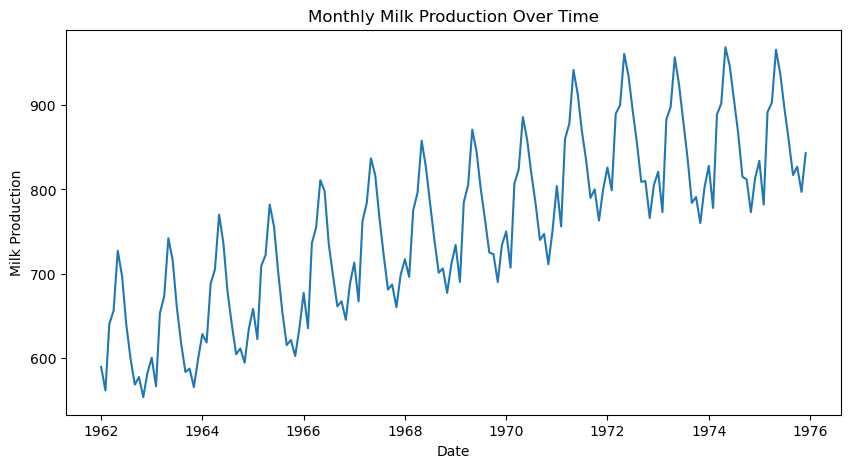

In [27]:
# 🔹 Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

#  Load dataset
df = pd.read_csv("monthly_milk_production.csv")

#  Clean column names (remove spaces)
df.columns = df.columns.str.strip()

#  Display columns
print("Columns:", df.columns)

#  Rename columns safely (adjust automatically)
df.columns = ['Date', 'Milk']

#  Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

#  Set index
df.set_index('Date', inplace=True)

#  Display first rows
print(df.head())

# Plot Trend (Time Series)

plt.figure(figsize=(10,5))
plt.plot(df['Milk'])
plt.title("Monthly Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.show()


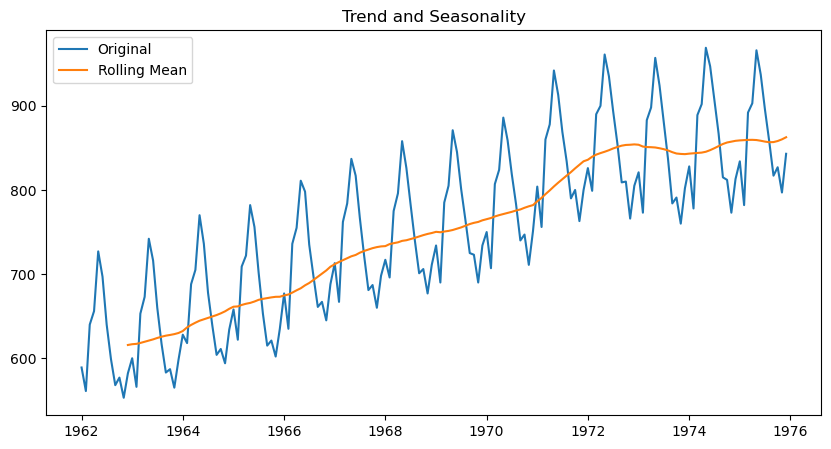

In [28]:
# Rolling Mean (Trend + Seasonality)


df['rolling_mean'] = df['Milk'].rolling(window=12).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Milk'], label='Original')
plt.plot(df['rolling_mean'], label='Rolling Mean')
plt.legend()
plt.title("Trend and Seasonality")
plt.show()

In [29]:
# 3. Check Missing Values
df.isnull().sum()

Milk             0
rolling_mean    11
dtype: int64

In [30]:
df['rolling_mean'] = df['rolling_mean'].bfill()

In [31]:
df.isnull().sum()

Milk            0
rolling_mean    0
dtype: int64

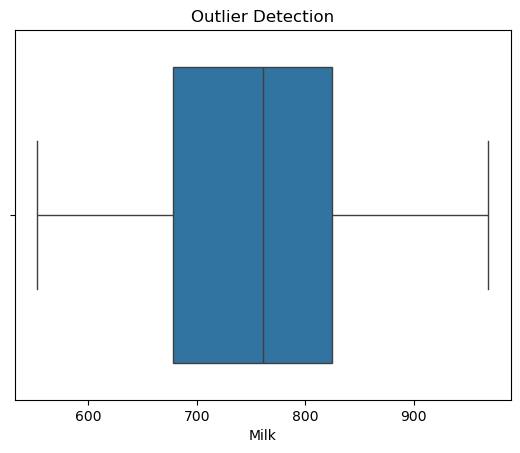

In [32]:

#4. Outlier Detection (Boxplot)
sns.boxplot(x=df['Milk'])
plt.title("Outlier Detection")
plt.show()

In [33]:

# Data Normalization


scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[['Milk']])

print("\nScaled Data Sample:\n", df_scaled[:5])


Scaled Data Sample:
 [[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


In [34]:
import numpy as np

# Use scaled data
data = df_scaled   # from previous step

# Function to create sequences
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

# Create sequences
X, y = create_sequences(data, window_size=12)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12, 1)
y shape: (156, 1)


In [35]:
# Split into train (70%), validation (15%), test (15%)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (109, 12, 1)
Validation: (23, 12, 1)
Test: (24, 12, 1)


In [36]:
# Reshape for neural network
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Reshaped X_train:", X_train.shape)

Reshaped X_train: (109, 12, 1)


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], 1)))
model_rnn.add(Dense(1))

model_rnn.compile(optimizer='adam', loss='mse')

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Epoch 1/20


C:\Users\Navya D C\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.1234 - val_loss: 0.1845
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0472 - val_loss: 0.0370
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0202 - val_loss: 0.0220
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0194 - val_loss: 0.0177
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0144 - val_loss: 0.0229
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0139 - val_loss: 0.0224
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0124 - val_loss: 0.0154
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0122 - val_loss: 0.0140
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0111 - val_loss: 0.0179
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0108 - val_loss: 0.0157
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0107 - val_loss: 0.0125
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0099 - val_loss: 0.0143
Epoch 13/20


In [38]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.1959 - val_loss: 0.3924
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1332 - val_loss: 0.2485
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0770 - val_loss: 0.1163
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0358 - val_loss: 0.0241
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0268 - val_loss: 0.0306
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0257 - val_loss: 0.0251
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0227 - val_loss: 0.0280
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0222 - val_loss: 0.0238
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0214 - val_loss: 0.0226
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0214 - val_loss: 0.0225
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0209 - val_loss: 0.0221
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0206 - val_loss: 0.0218
E

In [39]:
from tensorflow.keras.layers import GRU

model_gru = Sequential()
model_gru.add(GRU(50, activation='relu', input_shape=(X_train.shape[1], 1)))
model_gru.add(Dense(1))

model_gru.compile(optimizer='adam', loss='mse')

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(X_val, y_val)
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.2186 - val_loss: 0.4606
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1524 - val_loss: 0.3382
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1044 - val_loss: 0.2379
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0688 - val_loss: 0.1577
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0428 - val_loss: 0.0981
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0293 - val_loss: 0.0578
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0245 - val_loss: 0.0374
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0233 - val_loss: 0.0366
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0223 - val_loss: 0.0378
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0211 - val_loss: 0.0390
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0204 - val_loss: 0.0383
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0199 - val_loss: 0.0331
E

In [40]:
# Example tuned values
window_size = 12   # captures yearly seasonality
units = 64         # neurons in layer
epochs = 30        # number of training cycles
batch_size = 16    # samples per batch

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

# Tuned number of units
model.add(LSTM(units, activation='relu', input_shape=(window_size, 1)))

model.add(Dense(1))

# Tuned optimizer + loss
model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val)
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.1931 - val_loss: 0.4015
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1379 - val_loss: 0.2597
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0779 - val_loss: 0.1157
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0341 - val_loss: 0.0241
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0315 - val_loss: 0.0244
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0232 - val_loss: 0.0359
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0244 - val_loss: 0.0334
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0225 - val_loss: 0.0240
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0223 - val_loss: 0.0220
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0212 - val_loss: 0.0244
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0204 - val_loss: 0.0218
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0199 - val_loss: 0.0197
E

In [42]:
# Predictions
y_pred_rnn = model_rnn.predict(X_test)
y_pred_lstm = model_lstm.predict(X_test)
y_pred_gru = model_gru.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


In [43]:
# Inverse scaling
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

y_pred_rnn = scaler.inverse_transform(y_pred_rnn)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)
y_pred_gru = scaler.inverse_transform(y_pred_gru)

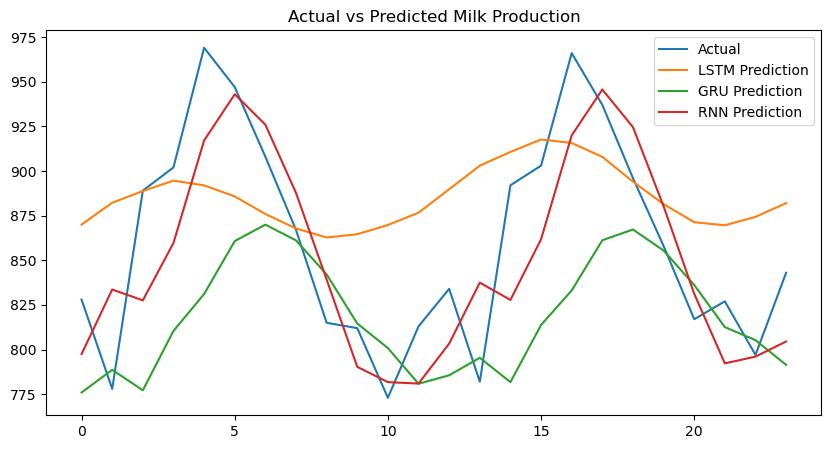

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred_lstm, label='LSTM Prediction')
plt.plot(y_pred_gru, label='GRU Prediction')
plt.plot(y_pred_rnn, label='RNN Prediction')

plt.legend()
plt.title("Actual vs Predicted Milk Production")
plt.show()

In [45]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

print("RNN:", calculate_metrics(y_test_actual, y_pred_rnn))
print("LSTM:", calculate_metrics(y_test_actual, y_pred_lstm))
print("GRU:", calculate_metrics(y_test_actual, y_pred_gru))

RNN: (np.float64(36.20774930835001), 31.535425821940095, np.float64(3.664755350487826))
LSTM: (np.float64(56.409464113949625), 46.41453043619793, np.float64(5.5546630746349575))
GRU: (np.float64(65.94470569596578), 50.76965077718099, np.float64(5.672487839385631))


In [46]:
# Get last sequence from dataset
last_sequence = X[-1]

future_predictions = []

current_input = last_sequence

for _ in range(12):  # predict next 12 months
    pred = model_lstm.predict(current_input.reshape(1, 12, 1))
    
    # Store prediction
    future_predictions.append(pred[0][0])
    
    # Update input sequence
    current_input = np.append(current_input[1:], pred)

# Convert to original scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

print("Next 12 Months Forecast:\n", future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Next 12 Months Forecast:
 [[882.0072 ]
 [902.492  ]
 [921.6042 ]
 [946.148  ]
 [953.16315]
 [953.5244 ]
 [939.5985 ]
 [926.90204]
 [922.8423 ]
 [931.148  ]
 [951.7952 ]
 [976.2424 ]]


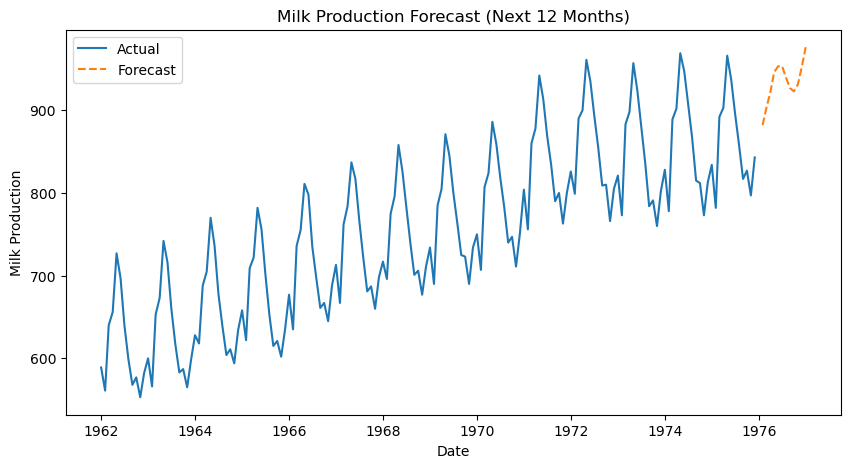

In [47]:
import matplotlib.pyplot as plt

# Plot original data
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Milk'], label='Actual')

# Create future index
future_dates = pd.date_range(
    start=df.index[-1], 
    periods=13, 
    freq='ME'
)[1:]

# Plot predictions
plt.plot(future_dates, future_predictions, label='Forecast', linestyle='dashed')

plt.title("Milk Production Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

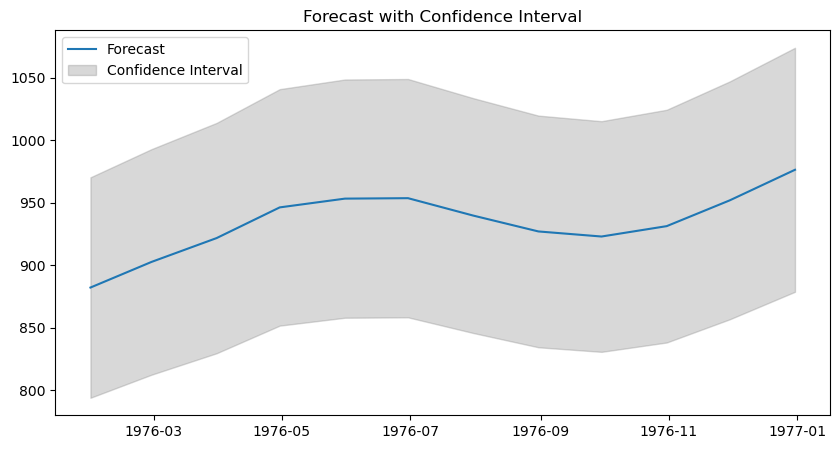

In [48]:
# Create confidence interval (±10%)
lower = future_predictions * 0.9
upper = future_predictions * 1.1

import matplotlib.pyplot as plt

# Confidence interval
lower = future_predictions * 0.9
upper = future_predictions * 1.1

plt.figure(figsize=(10,5))

plt.plot(future_dates, future_predictions, label='Forecast')

plt.fill_between(future_dates,
                 lower.flatten(),
                 upper.flatten(),
                 color='gray', alpha=0.3,
                 label='Confidence Interval')

plt.legend()
plt.title("Forecast with Confidence Interval")
plt.show()